# 04 — Benchmarking Tutorial
**(Notebook 4 / 5 — requires `01_dataset_generation.ipynb` + `03_training.ipynb`)**

This notebook shows how to benchmark a trained RL noise model against three baselines:

| Model | Description |
|---|---|
| **RL** | Trained RL agent applies learned per-gate noise parameters |
| **Randomized Benchmarking (RB)** | Single uniform depolarizing channel fitted from RB data |
| **No noise** | Noiseless simulation |
| **Maximally Mixed State (MMS)** | Trivial baseline — completely noisy state |

The comparison is visualised as **fidelity**, **trace distance**, and **MSE** vs circuit depth.

**Outputs written by this notebook:**
- `results/benchmarking/1q/` — 1-qubit benchmarking plots
- `results/benchmarking/3q/` — 3-qubit benchmarking plots
- `results/benchmarking/circuits/` — per-circuit (QFT, Grover, random) plots

## 1. Setup and Imports


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from rlnoise.config import (
    DatasetConfig, NoiseConfig, GateSpecificNoise,
    GymEnvConfig, RewardConfig, AgentConfig,
)
from rlnoise.dataset import DatasetGenerator, CircuitDataset
from rlnoise.circuit_encoder import CircuitEncoder
from rlnoise.circuit_generator import CircuitGenerator
from rlnoise.noise_model import QuantumNoiseModel
from rlnoise.gym_env import QuantumCircuitEnv
from rlnoise.rl_agent import RLAgent
from rlnoise.callback import TrainingCallback
from rlnoise.benchmarking import (
    generate_rb_circuits,
    fit_rb_decay,
    evaluate_benchmarks,
    summarize_benchmarks,
    summarize_rb_parameters,
)
from rlnoise.visualization import (
    plot_benchmarking_results,
    plot_rb_decay,
    plot_training_dashboard,
)

np.random.seed(42)

## 2. Load 1-Qubit Paper Dataset

We use the same noise model and dataset as in `experiments/1qubit/1qexperiment.py`
(and `03_training.ipynb` Section 4).  
**Run `01_dataset_generation.ipynb` (Section 4) first** to generate `datasets/dataset_1q.npz`.

In [ ]:
import os

# 1-qubit paper experiment configuration (matches experiments/1qubit/config.json)
N_QUBITS        = 1
PRIMITIVE_GATES = ["rx", "rz"]
TRAIN_DEPTH     = 10
VAL_SPLIT       = 0.2

noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping",      noise_parameter=0.03),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",   noise_parameter=0.04),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",   noise_parameter=0.02),
    ]
)

noise_model = QuantumNoiseModel(noise_config, qubits=N_QUBITS)
encoder     = CircuitEncoder(primitive_gates=PRIMITIVE_GATES)

DATASET_1Q_PATH = Path("datasets/dataset_1q.npz")
if not DATASET_1Q_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_1Q_PATH}'.\n"
        "Please run '01_dataset_generation.ipynb' (Section 4) first."
    )
dataset = CircuitDataset.load(str(DATASET_1Q_PATH))
print(f"Loaded dataset from '{DATASET_1Q_PATH}'")
print(dataset)
print(noise_config)


  CircuitDataset
    â€¢ Circuits:            50
    â€¢ Qubits:              1
    â€¢ Moments (depth):     10
    â€¢ Encoding dimension:  8
    â€¢ Circuit shape:       (10, 1, 8)


## 3. Load Pre-Trained 1-Qubit Agent

We load the agent saved by **Section 4** of `03_training.ipynb` (`agents/1q/model.zip`).  
The environment is reconstructed so that the model can run inference.

> **Prerequisite:** train and save the 1-qubit agent in `03_training.ipynb` before running this section.

In [ ]:
# Reconstruct the same environment the model was trained on
env_config = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.06,
    val_split=VAL_SPLIT,
    enable_only_depolarizing=False,
)

reward_config = RewardConfig(metric="trace", function="inverted_squared", alpha=20.0)

env = QuantumCircuitEnv(
    dataset=dataset,
    encoder=encoder,
    env_config=env_config,
    reward_config=reward_config,
)

agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,
    filter_size=1,
    n_filters=16,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=1000,
    batch_size=200,
    learning_rate=1e-4,
)

agent = RLAgent(env=env, agent_config=agent_config)
print(agent)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     3,609
  Trainable parameters: 3,609
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      2
  Policy net arch:      [32]
  Value net arch:       [32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           25
  N steps:              100
  Gamma:                0.99


In [ ]:
MODEL_1Q = "agents/1q/model"
if not Path(MODEL_1Q + ".zip").exists():
    raise FileNotFoundError(
        f"Trained agent not found at '{MODEL_1Q}.zip'.\n"
        "Please run '03_training.ipynb' (Section 4) first."
    )

agent.load(MODEL_1Q)
print(f"1-qubit model loaded from '{MODEL_1Q}'")

Output()

Step    2000 | Train reward: 1.6784 ± 0.2876  trace: 0.1745 ± 0.0151  |  Val reward: 1.7256 ± 0.2768  trace: 0.1720 ± 0.0145
Model saved in benchmarking_results/benchmarking1q


Step    4000 | Train reward: 1.6784 ± 0.2876  trace: 0.1745 ± 0.0151  |  Val reward: 1.7256 ± 0.2768  trace: 0.1720 ± 0.0145


Step    6000 | Train reward: 2.0150 ± 0.3828  trace: 0.1597 ± 0.0152  |  Val reward: 2.0913 ± 0.3870  trace: 0.1567 ± 0.0149
Model saved in benchmarking_results/benchmarking1q


Step    8000 | Train reward: 1.6840 ± 0.2890  trace: 0.1742 ± 0.0151  |  Val reward: 1.7306 ± 0.2783  trace: 0.1717 ± 0.0146


...

Step   16000 | Train reward: 13.0448 ± 6.8613  trace: 0.0691 ± 0.0194  |  Val reward: 15.4872 ± 8.4336  trace: 0.0644 ± 0.0202


Model saved in benchmarking_results/benchmarking1q


Step   18000 | Train reward: 9.0908 ± 3.9885  trace: 0.0800 ± 0.0185  |  Val reward: 10.2366 ± 4.4645  trace: 0.0758 ± 0.0191


Step   20000 | Train reward: 4.7276 ± 1.4609  trace: 0.1067 ± 0.0170  |  Val reward: 5.0559 ± 1.4952  trace: 0.1032 ± 0.0171


Loaded best model weights from benchmarking_results/benchmarking1q


In [ ]:
from rlnoise.callback import TrainingCallback
from rlnoise.visualization import plot_training_dashboard

os.makedirs("results/benchmarking/1q", exist_ok=True)

HISTORY_1Q = "results/training/1q/history.npz"
if Path(HISTORY_1Q).exists():
    history_1q = TrainingCallback.load_history(HISTORY_1Q)
    fig = plot_training_dashboard(
        history_1q,
        title="1-Qubit Training Progress",
        filepath="results/benchmarking/1q/training_dashboard.png",
        show_reward=True,
        show_trace_distance=False,
        show_fidelity=True,
    )
    plt.show()
else:
    print(f"No training history at '{HISTORY_1Q}'. Run '03_training.ipynb' Section 4 first.")

NameError: name 'train_results' is not defined

## 4. Generate the RB Dataset

We generate random Clifford circuits at multiple depths.  
For each circuit the **target density matrix** is computed by simulating the circuit through
the ground-truth noise model — these become the labels used for evaluation.

The RB protocol will later run each circuit **followed by its own inverse**; ideally (without noise)
this returns the system to |0⟩, and the survival probability P(|0⟩) decays as noise increases.


In [12]:
RB_DEPTHS              = [5, 10, 15, 20, 25]   # circuit depths to sweep over
N_CIRCUITS_PER_DEPTH   = 20                  # circuits evaluated at each depth

# CircuitGenerator is used to create circuits at varying depths
circuit_gen = CircuitGenerator(
    DatasetConfig(
        n_circuits=N_CIRCUITS_PER_DEPTH,
        moments=RB_DEPTHS[0],          # will be overridden per depth
        qubits=N_QUBITS,
        primitive_gates=PRIMITIVE_GATES,
        clifford=True,
    )
)

print("Generating RB dataset…")
rb_data = generate_rb_circuits(
    circuit_gen=circuit_gen,
    encoder=encoder,
    noise_model=noise_model,
    depths=RB_DEPTHS,
    n_circuits_per_depth=N_CIRCUITS_PER_DEPTH,
)

print(f"\nRB dataset: {len(rb_data)} depths × {N_CIRCUITS_PER_DEPTH} circuits")
for entry in rb_data:
    print(f"  depth={entry['depth']:3d}  "
          f"circuit_arrays={entry['circuit_arrays'].shape}  "
          f"labels={entry['labels'].shape}")


Generating RB dataset…
  Generating 20 circuits of depth 5…
  Generating 20 circuits of depth 10…
  Generating 20 circuits of depth 15…
  Generating 20 circuits of depth 20…
  Generating 20 circuits of depth 25…

RB dataset: 5 depths × 20 circuits
  depth=  5  circuit_arrays=(20, 5, 1, 8)  labels=(20, 2, 2)
  depth= 10  circuit_arrays=(20, 10, 1, 8)  labels=(20, 2, 2)
  depth= 15  circuit_arrays=(20, 15, 1, 8)  labels=(20, 2, 2)
  depth= 20  circuit_arrays=(20, 20, 1, 8)  labels=(20, 2, 2)
  depth= 25  circuit_arrays=(20, 25, 1, 8)  labels=(20, 2, 2)


## 5. Fit the RB Decay Curve

Randomized benchmarking fits the survival probability $P(|0\rangle)$ to an exponential model
$$P(d) = a \cdot \lambda^d$$
where $\lambda$ is the decay constant and $p = 1-\lambda$ is the effective depolarizing error per Clifford gate.
We will use $\lambda$ later to build the uniform depolarizing baseline noise model for comparison.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


RB fit parameters:
  a        = 0.8937
  lambda   = 0.9805
  p (eff.) = 1 - lambda = 0.0195


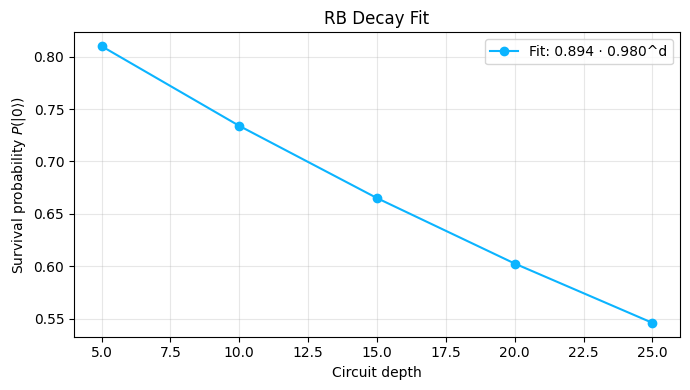

In [ ]:
a, lambda_rb = fit_rb_decay(rb_data, noise_model)

summarize_rb_parameters(a, lambda_rb)

fig = plot_rb_decay(
    rb_data, a=a, lambda_rb=lambda_rb,
    title="1-Qubit RB Decay Fit",
    filepath="results/benchmarking/1q/rb_decay.png",
)
plt.show()

## 6. Evaluate All Models

We now evaluate four models on the same RB circuits at every depth:

| Model | Description |
|---|---|
| **RL** | The trained PPO agent predicts noise parameters for each circuit |
| **RB** | Uniform depolarizing noise calibrated via the fitted $\lambda_\text{RB}$ |
| **No noise** | Ideal simulation — zero noise applied |
| **MMS** | Maximally mixed state — worst-case baseline |

For each model we compute average fidelity, trace distance, and MSE w.r.t. the noisy labels.


In [ ]:
print("Evaluating all models on 1-qubit RB circuits…")
bench_results = evaluate_benchmarks(
    rb_data=rb_data,
    encoder=encoder,
    rl_agent=agent,
    lambda_rb=lambda_rb,   # pass None to skip RB baseline
    evaluate_no_noise=True,
    evaluate_mms=True,
)

# Built-in formatted summary table
summarize_benchmarks(bench_results)

Evaluating all models on RB circuits…
  Evaluating depth 5 (20 circuits)…
  Evaluating depth 10 (20 circuits)…
  Evaluating depth 15 (20 circuits)…
  Evaluating depth 20 (20 circuits)…
  Evaluating depth 25 (20 circuits)…

 Depth       Model    Fidelity       Trace           MSE
--------------------------------------------------------
     5          rl      0.9950      0.0441      0.001037
     5          rb      0.9903      0.0556      0.001599
     5    no_noise      0.9051      0.0991      0.004952
     5         mms      0.7914      0.4061      0.082479

    10          rl      0.9914      0.0724      0.002848
    10          rb      0.9834      0.0935      0.004544
    10    no_noise      0.8303      0.1768      0.015719
    10         mms      0.8718      0.3342      0.055867

    15          rl      0.9898      0.0843      0.003666
    15          rb      0.9790      0.1147      0.006691
    15    no_noise      0.7660      0.2380      0.028437
    15         mms      0.9207    

## 7. Plot Benchmarking Results


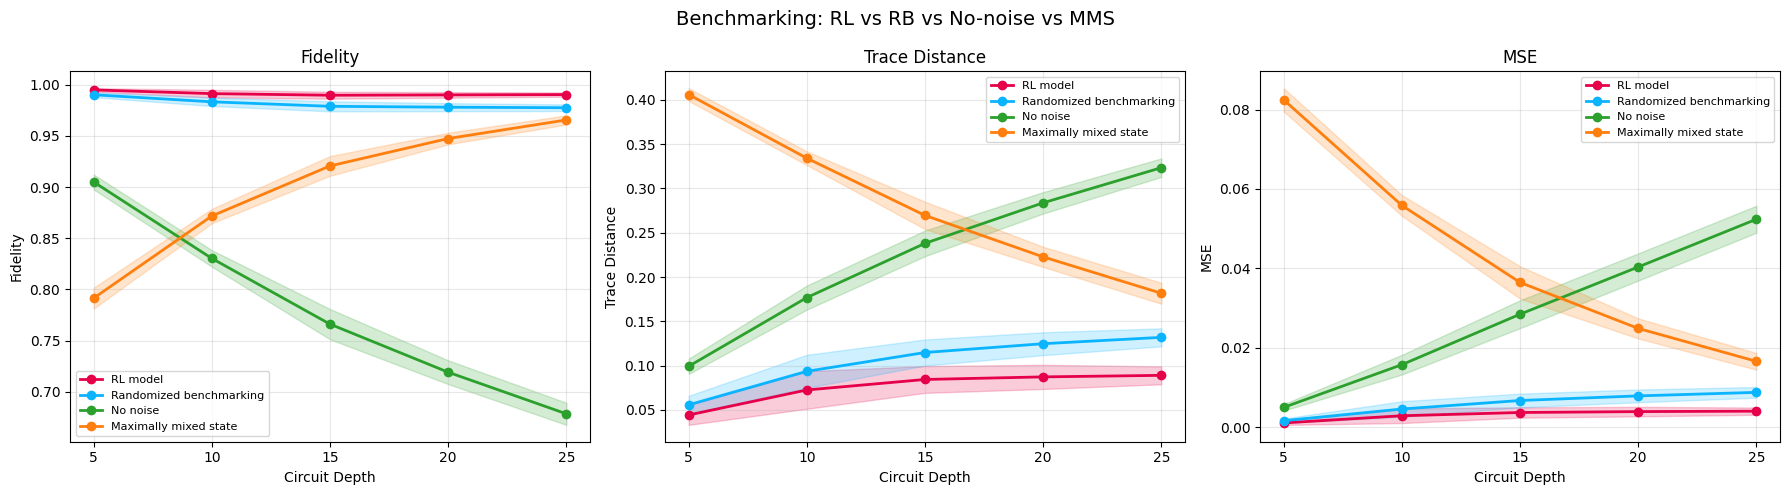

In [ ]:
fig = plot_benchmarking_results(
    bench_results,
    title="1-Qubit Benchmarking: RL vs RB vs No-noise vs MMS",
    filepath="results/benchmarking/1q/comparison.png",
    show_fidelity=True,
    show_trace=True,
    show_mse=True,
)
plt.show()

## 7b. RL-Only Depth Sweep

Sometimes you only want to inspect how the **RL model alone** generalises to
different circuit depths — without computing the other baselines.

Pass `lambda_rb=None` to skip the RB baseline and set
`evaluate_no_noise=False` / `evaluate_mms=False` to skip the remaining
baselines.  The plot and table automatically adapt to whatever models are
present in the results dict.

In [ ]:
rl_only_results = evaluate_benchmarks(
    rb_data=rb_data,
    encoder=encoder,
    rl_agent=agent,
    lambda_rb=None,
    evaluate_no_noise=False,
    evaluate_mms=False,
)

summarize_benchmarks(rl_only_results)

fig = plot_benchmarking_results(
    rl_only_results,
    title="RL Model: Fidelity vs Circuit Depth",
    filepath="results/benchmarking/1q/rl_only_fidelity.png",
    show_fidelity=True,
    show_trace=False,
    show_mse=False,
)
plt.show()

## 8. 3-Qubit Benchmarking

We now repeat the full evaluation for the 3-qubit model trained in **Section 5** of `03_training.ipynb`
(`agents/3q/model.zip`).  
The noise model and dataset match `experiments/3qubit/config.json` (3q_high setup).

> **Prerequisite:** train and save the 3-qubit agent in `03_training.ipynb` Section 5 before running this section.

In [ ]:
N_QUBITS_3Q        = 3
PRIMITIVE_GATES_3Q = ["rz", "rx", "cz"]
VAL_SPLIT_3Q       = 0.2

noise_config_3q = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rz", noise_channel="depolarizing", noise_parameter=0.02),
        GateSpecificNoise(gate="cz", noise_channel="depolarizing", noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping",      noise_parameter=0.03),
        GateSpecificNoise(gate="cz", noise_channel="damping",      noise_parameter=0.03),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",   noise_parameter=0.04),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",   noise_parameter=0.03),
    ]
)

noise_model_3q = QuantumNoiseModel(noise_config_3q, qubits=N_QUBITS_3Q)
encoder_3q     = CircuitEncoder(primitive_gates=PRIMITIVE_GATES_3Q)

DATASET_3Q_PATH = Path("datasets/dataset_3q.npz")
if not DATASET_3Q_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_3Q_PATH}'.\n"
        "Please run '01_dataset_generation.ipynb' (Section 4) first."
    )
dataset_3q = CircuitDataset.load(str(DATASET_3Q_PATH))
print(f"Loaded dataset from '{DATASET_3Q_PATH}'")
print(dataset_3q)
print(noise_config_3q)

In [ ]:
env_config_3q = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.06,
    val_split=VAL_SPLIT_3Q,
    enable_only_depolarizing=False,
)

reward_config_3q = RewardConfig(metric="trace", function="inverted_squared", alpha=20.0)

env_3q = QuantumCircuitEnv(
    dataset=dataset_3q,
    encoder=encoder_3q,
    env_config=env_config_3q,
    reward_config=reward_config_3q,
)

agent_config_3q = AgentConfig(
    policy="MlpPolicy",
    features_dim=64,
    filter_size=1,
    n_filters=32,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=2000,
    batch_size=400,
    learning_rate=1e-4,
)

agent_3q = RLAgent(env=env_3q, agent_config=agent_config_3q)

MODEL_3Q = "agents/3q/model"
if not Path(MODEL_3Q + ".zip").exists():
    raise FileNotFoundError(
        f"Trained agent not found at '{MODEL_3Q}.zip'.\n"
        "Please run '03_training.ipynb' (Section 5) first."
    )
agent_3q.load(MODEL_3Q)
print(f"3-qubit model loaded from '{MODEL_3Q}'")

In [ ]:
os.makedirs("results/benchmarking/3q", exist_ok=True)

HISTORY_3Q = "results/training/3q/history.npz"
if Path(HISTORY_3Q).exists():
    history_3q = TrainingCallback.load_history(HISTORY_3Q)
    fig = plot_training_dashboard(
        history_3q,
        title="3-Qubit Training Progress",
        filepath="results/benchmarking/3q/training_dashboard.png",
        show_reward=True,
        show_trace_distance=False,
        show_fidelity=True,
    )
    plt.show()
else:
    print(f"No training history at '{HISTORY_3Q}'. Run '03_training.ipynb' Section 5 first.")

### 8.1 3-Qubit RB Dataset

In [ ]:
RB_DEPTHS_3Q            = [3, 6, 9, 12, 15, 18, 21]
N_CIRCUITS_PER_DEPTH_3Q = 20

circuit_gen_3q = CircuitGenerator(
    DatasetConfig(
        n_circuits=N_CIRCUITS_PER_DEPTH_3Q,
        moments=RB_DEPTHS_3Q[0],
        qubits=N_QUBITS_3Q,
        primitive_gates=PRIMITIVE_GATES_3Q,
        clifford=True,
    )
)

print("Generating 3-qubit RB dataset…")
rb_data_3q = generate_rb_circuits(
    circuit_gen=circuit_gen_3q,
    encoder=encoder_3q,
    noise_model=noise_model_3q,
    depths=RB_DEPTHS_3Q,
    n_circuits_per_depth=N_CIRCUITS_PER_DEPTH_3Q,
)

print(f"\nRB dataset: {len(rb_data_3q)} depths × {N_CIRCUITS_PER_DEPTH_3Q} circuits")

### 8.2 Fit RB Decay (3-Qubit)

In [ ]:
a_3q, lambda_rb_3q = fit_rb_decay(rb_data_3q, noise_model_3q)

summarize_rb_parameters(a_3q, lambda_rb_3q)

fig = plot_rb_decay(
    rb_data_3q, a=a_3q, lambda_rb=lambda_rb_3q,
    color="#e60049",
    title="3-Qubit RB Decay Fit",
    filepath="results/benchmarking/3q/rb_decay.png",
)
plt.show()

### 8.3 Evaluate and Plot (3-Qubit)

In [ ]:
print("Evaluating all models on 3-qubit RB circuits…")
bench_results_3q = evaluate_benchmarks(
    rb_data=rb_data_3q,
    encoder=encoder_3q,
    rl_agent=agent_3q,
    lambda_rb=lambda_rb_3q,
    evaluate_no_noise=True,
    evaluate_mms=True,
)

summarize_benchmarks(bench_results_3q)

fig = plot_benchmarking_results(
    bench_results_3q,
    title="3-Qubit Benchmarking: RL vs RB vs No-noise vs MMS",
    filepath="results/benchmarking/3q/comparison.png",
    show_fidelity=True,
    show_trace=True,
    show_mse=True,
)
plt.show()

## 9. Single-Circuit Benchmarking: QFT, Grover and Random

Beyond randomised benchmarking over many circuits, we often want to evaluate how
well each noise model reproduces the output of a *specific* algorithm.

This section demonstrates **`evaluate_circuit`**, which runs a single Qibo circuit
through every active model and returns the density matrices together with
fidelity, trace distance and MSE.  Three built-in circuits are available:

| Function | Description |
|---|---|
| `qft_circuit()` | 3-qubit Quantum Fourier Transform |
| `grover_circuit()` | 3-qubit Grover search (target: &#124;11x⟩) |
| `CircuitGenerator.generate_random_circuit()` | One random circuit from the training distribution |

Three companion plot functions visualise the results:

| Function | What it shows |
|---|---|
| `plot_shots` | Basis-state probabilities (diagonal of ρ) per model |
| `plot_density_matrix_heatmap` | Element-wise &#124;ρ_truth − ρ_model&#124; |
| `plot_circuit_metrics` | Bar chart of fidelity / trace / MSE per model |

> **Note:** QFT and Grover are 3-qubit circuits, so we reuse the
> 3-qubit noise model, encoder and RL agent from Section 8.

### 9.1 Quantum Fourier Transform

In [ ]:
import os
from rlnoise import (
    qft_circuit, grover_circuit,
    evaluate_circuit, summarize_circuit_metrics,
    plot_shots, plot_density_matrix_heatmap, plot_circuit_metrics,
)

os.makedirs("results/benchmarking/circuits", exist_ok=True)

circ_qft = qft_circuit()
print(f"QFT circuit — {circ_qft.nqubits} qubits, {len(circ_qft.queue)} gates")

qft_results = evaluate_circuit(
    circuit=circ_qft,
    encoder=encoder_3q,
    rl_agent=agent_3q,
    noise_model=noise_model_3q,
    lambda_rb=lambda_rb_3q,
    evaluate_no_noise=True,
    evaluate_mms=True,
)

summarize_circuit_metrics(qft_results)

In [ ]:
fig = plot_shots(
    qft_results,
    show_truth=True, show_rl=True, show_rb=True,
    show_no_noise=True, show_mms=False,
    title="QFT — Basis-state Probabilities",
    filepath="results/benchmarking/circuits/qft_shots.png",
)
plt.show()

In [ ]:
fig = plot_density_matrix_heatmap(
    qft_results,
    show_rl=True, show_rb=True, show_no_noise=False, show_mms=False,
    cmap="plasma",
    title="QFT — |ρ_truth − ρ_model|",
    filepath="results/benchmarking/circuits/qft_heatmap.png",
)
plt.show()

In [ ]:
fig = plot_circuit_metrics(
    qft_results,
    show_fidelity=True, show_trace=True, show_mse=True,
    title="QFT — Model Performance",
    filepath="results/benchmarking/circuits/qft_metrics.png",
)
plt.show()

### 9.2 Grover Search Circuit

In [ ]:
circ_grover = grover_circuit()
print(f"Grover circuit — {circ_grover.nqubits} qubits, {len(circ_grover.queue)} gates")

grover_results = evaluate_circuit(
    circuit=circ_grover,
    encoder=encoder_3q,
    rl_agent=agent_3q,
    noise_model=noise_model_3q,
    lambda_rb=lambda_rb_3q,
    evaluate_no_noise=True,
    evaluate_mms=True,
)

summarize_circuit_metrics(grover_results)

In [ ]:
fig = plot_shots(
    grover_results,
    show_truth=True, show_rl=True, show_rb=True,
    show_no_noise=True, show_mms=False,
    title="Grover — Basis-state Probabilities",
    filepath="results/benchmarking/circuits/grover_shots.png",
)
plt.show()

fig = plot_density_matrix_heatmap(
    grover_results,
    show_rl=True, show_rb=True, show_no_noise=False, show_mms=False,
    cmap="plasma",
    title="Grover — |ρ_truth − ρ_model|",
    filepath="results/benchmarking/circuits/grover_heatmap.png",
)
plt.show()

fig = plot_circuit_metrics(
    grover_results,
    show_fidelity=True, show_trace=True, show_mse=True,
    title="Grover — Model Performance",
    filepath="results/benchmarking/circuits/grover_metrics.png",
)
plt.show()

### 9.3 Single Random Circuit

Testing on one random circuit sampled from the training distribution shows
how well the RL agent generalises to out-of-sample inputs at a given depth.
Here we reuse the 1-qubit setup for a quick comparison.

In [ ]:
np.random.seed(0)  # reproducibility
circ_rand = circuit_gen.generate_random_circuit()
print(f"Random circuit — {circ_rand.nqubits} qubit, {len(circ_rand.queue)} gates, "
      f"{len(circ_rand.queue.moments)} moments")
print(circ_rand.draw())

rand_results = evaluate_circuit(
    circuit=circ_rand,
    encoder=encoder,
    rl_agent=agent,
    noise_model=noise_model,
    lambda_rb=lambda_rb,        # set to None to skip RB baseline
    evaluate_no_noise=True,
    evaluate_mms=True,
)

summarize_circuit_metrics(rand_results)

In [ ]:
fig = plot_shots(
    rand_results,
    show_truth=True, show_rl=True, show_rb=True,
    show_no_noise=True, show_mms=False,
    title="Random Circuit — Basis-state Probabilities",
    filepath="results/benchmarking/circuits/random_shots.png",
)
plt.show()

fig = plot_density_matrix_heatmap(
    rand_results,
    show_rl=True, show_rb=True, show_no_noise=False, show_mms=False,
    cmap="plasma",
    title="Random Circuit — |ρ_truth − ρ_model|",
    filepath="results/benchmarking/circuits/random_heatmap.png",
)
plt.show()

fig = plot_circuit_metrics(
    rand_results,
    show_fidelity=True, show_trace=True, show_mse=False,
    title="Random Circuit — Model Performance",
    filepath="results/benchmarking/circuits/random_metrics.png",
)
plt.show()